# Evaluation Metrics Pipeline

This notebook runs an end-to-end evaluation workflow for two RAG strategies:

- **Strategy A**: Hybrid Retrieval (BM25 + Vector)
- **Strategy B**: Hybrid Retrieval + Rerank

It generates predictions, computes metrics against ground truth, and summarizes results.

## Metrics
- Retrieval: Recall@K, Precision@K, MRR@K, nDCG@K, MAP@K
- Generation: Exact Match, Token F1, ROUGE-L
- Citation (if available): Citation hit rate

In [49]:
from pathlib import Path
import subprocess
import json

try:
    import pandas as pd
except Exception:
    pd = None

def find_repo_root(start: Path) -> Path:
    p = start.resolve()
    for cur in [p] + list(p.parents):
        if (cur / "config.py").exists() and (cur / "scripts").exists() and (cur / "data").exists():
            return cur
    raise RuntimeError("Cannot find repository root")

ROOT = find_repo_root(Path.cwd())
print("Repository root:", ROOT)

Repository root: /Users/ben/Library/CloudStorage/GoogleDrive-rs.runsheng@gmail.com/My Drive/Colab Notebooks/CS614 GenAI/qa_agent_legal_tax


## 1) Install dependencies

Run once if needed.

In [50]:
import sys


def run(cmd):
    normalized_cmd = list(cmd)
    if normalized_cmd and normalized_cmd[0] == "python":
        normalized_cmd[0] = sys.executable
    print("\n$", " ".join(normalized_cmd))
    subprocess.run(normalized_cmd, cwd=ROOT, check=True)


MINIMAL_PACKAGES = [
    "pip==26.0.1",
    "setuptools==82.0.1",
    "wheel==0.46.3",
    "python-dotenv>=1.0.0",
    "pyyaml==6.0.1",
    "openai==1.66.0",
    "google-genai==1.66.0",
    "pydantic>=2.9.0,<3.0.0",
    "numpy>=1.26.4,<2.0",
    "pandas>=2.2.2,<2.3",
    "python-dateutil>=2.8.2",
    "rouge-score>=0.1.2",
    "rank-bm25>=0.2.2",
    "cohere>=5.11.0",
]

run([
    sys.executable,
    "-m",
    "pip",
    "install",
    "--no-cache-dir",
    "--prefer-binary",
    "--upgrade-strategy",
    "only-if-needed",
    *MINIMAL_PACKAGES,
])


$ /opt/anaconda3/bin/python -m pip install --no-cache-dir --prefer-binary --upgrade-strategy only-if-needed pip==26.0.1 setuptools==82.0.1 wheel==0.46.3 python-dotenv>=1.0.0 pyyaml==6.0.1 openai==1.66.0 google-genai==1.66.0 pydantic>=2.9.0,<3.0.0 numpy>=1.26.4,<2.0 pandas>=2.2.2,<2.3 python-dateutil>=2.8.2 rouge-score>=0.1.2 rank-bm25>=0.2.2 cohere>=5.11.0


## 2) Configure input/output paths

In [51]:
GT = ROOT / "data" / "qa_pairs" / "eval_ground_truth.jsonl"
if not GT.exists():
    print(f"Ground truth file not found, generating: {GT}")
    gen_script = ROOT / "scripts" / "eval" / "generate_eval_ground_truth.py"
    if not gen_script.exists():
        raise FileNotFoundError(f"Ground truth generator script not found: {gen_script}")

    run([
        "python", str(gen_script), "--out", str(GT)
    ])

    if not GT.exists():
        raise FileNotFoundError(f"Failed to generate ground truth file: {GT}")

PRED_HYBRID = ROOT / "outputs" / "preds_hybrid.jsonl"
PRED_HYBRID_RERANK = ROOT / "outputs" / "preds_hybrid_rerank.jsonl"

EVAL_HYBRID = ROOT / "outputs" / "eval_hybrid.json"
EVAL_HYBRID_RERANK = ROOT / "outputs" / "eval_hybrid_rerank.json"

EVAL_GEN_HYBRID = ROOT / "outputs" / "eval_gen_hybrid.json"
EVAL_GEN_HYBRID_RERANK = ROOT / "outputs" / "eval_gen_hybrid_rerank.json"

print("Ground truth:", GT)

Ground truth: /Users/ben/Library/CloudStorage/GoogleDrive-rs.runsheng@gmail.com/My Drive/Colab Notebooks/CS614 GenAI/qa_agent_legal_tax/data/qa_pairs/eval_ground_truth.jsonl


## 3) Generate predictions for both RAG strategies

In [52]:
import os
from dotenv import load_dotenv

# Re-read .env every time this cell runs, overriding any stale values
load_dotenv(ROOT / ".env", override=True)

for name in ["OPENAI_API_KEY", "GOOGLE_API_KEY"]:
    val = os.getenv(name)
    if val:
        print(f"[debug] {name}=****{val[-4:]}")
    else:
        print(f"[debug] {name}=<missing>")
        

# Strategy A: Hybrid Retrieval (BM25 + Vector)
run([
    "python", "scripts/eval/run_eval_benchmark.py",
    "--gt", str(GT),
    "--out", str(PRED_HYBRID),
    "--enable-rerank", "false"
])

# Strategy B: Hybrid Retrieval + Rerank
run([
    "python", "scripts/eval/run_eval_benchmark.py",
    "--gt", str(GT),
    "--out", str(PRED_HYBRID_RERANK),
    "--enable-rerank", "true"
])


[debug] OPENAI_API_KEY=****here
[debug] GOOGLE_API_KEY=****Jaoo

$ /opt/anaconda3/bin/python scripts/eval/run_eval_benchmark.py --gt /Users/ben/Library/CloudStorage/GoogleDrive-rs.runsheng@gmail.com/My Drive/Colab Notebooks/CS614 GenAI/qa_agent_legal_tax/data/qa_pairs/eval_ground_truth.jsonl --out /Users/ben/Library/CloudStorage/GoogleDrive-rs.runsheng@gmail.com/My Drive/Colab Notebooks/CS614 GenAI/qa_agent_legal_tax/outputs/preds_hybrid.jsonl --enable-rerank false
[debug] QAAgent.__init__ signature: (self, retriever, llm_service, validator, config: Dict)
[debug] cfg_dict keys (52): ['ACTS_CHUNKED_DIR', 'ACTS_CSV', 'ACTS_HTML_DIR', 'ACTS_MD_DIR', 'BM25_B', 'BM25_K1', 'CHUNK_OVERLAP', 'CHUNK_SIZE', 'COHERE_API_KEY', 'COHERE_RERANK_MODEL', 'DATA_DIR', 'DEBUG', 'DOCS_DIR', 'EMBEDDING_DIMENSION', 'EMBEDDING_MODEL', 'EMBEDDING_PROVIDER', 'ENABLE_KG', 'ENABLE_RERANK', 'FINANCIAL_TEMPLATES_DIR', 'GEMINI_API_VERSION', 'GEMINI_EMBEDDING_MODEL', 'GEMINI_LLM_MODEL', 'GOOGLE_API_KEY', 'HYBRID_ALPH

Cohere rerank skipped: no non-empty candidate documents.
Cohere rerank skipped: no non-empty candidate documents.


Saved predictions: /Users/ben/Library/CloudStorage/GoogleDrive-rs.runsheng@gmail.com/My Drive/Colab Notebooks/CS614 GenAI/qa_agent_legal_tax/outputs/preds_hybrid.jsonl (n=2)
[snapshot] Saved run config snapshot: /Users/ben/Library/CloudStorage/GoogleDrive-rs.runsheng@gmail.com/My Drive/Colab Notebooks/CS614 GenAI/qa_agent_legal_tax/outputs/run_snapshot_20260313_012220.json

$ /opt/anaconda3/bin/python scripts/eval/run_eval_benchmark.py --gt /Users/ben/Library/CloudStorage/GoogleDrive-rs.runsheng@gmail.com/My Drive/Colab Notebooks/CS614 GenAI/qa_agent_legal_tax/data/qa_pairs/eval_ground_truth.jsonl --out /Users/ben/Library/CloudStorage/GoogleDrive-rs.runsheng@gmail.com/My Drive/Colab Notebooks/CS614 GenAI/qa_agent_legal_tax/outputs/preds_hybrid_rerank.jsonl --enable-rerank true
[debug] QAAgent.__init__ signature: (self, retriever, llm_service, validator, config: Dict)
[debug] cfg_dict keys (52): ['ACTS_CHUNKED_DIR', 'ACTS_CSV', 'ACTS_HTML_DIR', 'ACTS_MD_DIR', 'BM25_B', 'BM25_K1', 'CHUNK

Cohere rerank skipped: no non-empty candidate documents.
Cohere rerank skipped: no non-empty candidate documents.


Saved predictions: /Users/ben/Library/CloudStorage/GoogleDrive-rs.runsheng@gmail.com/My Drive/Colab Notebooks/CS614 GenAI/qa_agent_legal_tax/outputs/preds_hybrid_rerank.jsonl (n=2)
[snapshot] Saved run config snapshot: /Users/ben/Library/CloudStorage/GoogleDrive-rs.runsheng@gmail.com/My Drive/Colab Notebooks/CS614 GenAI/qa_agent_legal_tax/outputs/run_snapshot_20260313_012234.json


## 4) Compute evaluation metrics (retrieval + generation)

In [53]:
run([
    "python", "scripts/eval/evaluate_predictions.py",
    "--gt", str(GT),
    "--pred", str(PRED_HYBRID),
    "--k", "5",
    "--out", str(EVAL_HYBRID)
])

run([
    "python", "scripts/eval/evaluate_predictions.py",
    "--gt", str(GT),
    "--pred", str(PRED_HYBRID_RERANK),
    "--k", "5",
    "--out", str(EVAL_HYBRID_RERANK)
])


$ /opt/anaconda3/bin/python scripts/eval/evaluate_predictions.py --gt /Users/ben/Library/CloudStorage/GoogleDrive-rs.runsheng@gmail.com/My Drive/Colab Notebooks/CS614 GenAI/qa_agent_legal_tax/data/qa_pairs/eval_ground_truth.jsonl --pred /Users/ben/Library/CloudStorage/GoogleDrive-rs.runsheng@gmail.com/My Drive/Colab Notebooks/CS614 GenAI/qa_agent_legal_tax/outputs/preds_hybrid.jsonl --k 5 --out /Users/ben/Library/CloudStorage/GoogleDrive-rs.runsheng@gmail.com/My Drive/Colab Notebooks/CS614 GenAI/qa_agent_legal_tax/outputs/eval_hybrid.json
{
  "retrieval": {
    "recall@5": 0.0,
    "precision@5": 0.0,
    "ndcg@5": 0.0,
    "mrr@5": 0.0,
    "map@5": 0.0
  },
  "generation": {
    "exact_match": 0.0,
    "token_f1": 0.07742955491514569,
    "rougeL_f1": 0.0636734693877551,
    "citation_hit_rate": 0.0
  },
  "meta": {
    "num_questions": 2,
    "k": 5
  }
}

$ /opt/anaconda3/bin/python scripts/eval/evaluate_predictions.py --gt /Users/ben/Library/CloudStorage/GoogleDrive-rs.runsheng@g

## 5) Optional: generation-only metrics

In [54]:
run([
    "python", "scripts/eval/evaluate_generation.py",
    "--gt", str(GT),
    "--pred", str(PRED_HYBRID),
    "--out", str(EVAL_GEN_HYBRID)
])

run([
    "python", "scripts/eval/evaluate_generation.py",
    "--gt", str(GT),
    "--pred", str(PRED_HYBRID_RERANK),
    "--out", str(EVAL_GEN_HYBRID_RERANK)
])


$ /opt/anaconda3/bin/python scripts/eval/evaluate_generation.py --gt /Users/ben/Library/CloudStorage/GoogleDrive-rs.runsheng@gmail.com/My Drive/Colab Notebooks/CS614 GenAI/qa_agent_legal_tax/data/qa_pairs/eval_ground_truth.jsonl --pred /Users/ben/Library/CloudStorage/GoogleDrive-rs.runsheng@gmail.com/My Drive/Colab Notebooks/CS614 GenAI/qa_agent_legal_tax/outputs/preds_hybrid.jsonl --out /Users/ben/Library/CloudStorage/GoogleDrive-rs.runsheng@gmail.com/My Drive/Colab Notebooks/CS614 GenAI/qa_agent_legal_tax/outputs/eval_gen_hybrid.json
{
  "num_questions": 2,
  "exact_match": 0.0,
  "token_f1": 0.07742955491514569,
  "rougeL_f1": 0.0636734693877551
}

$ /opt/anaconda3/bin/python scripts/eval/evaluate_generation.py --gt /Users/ben/Library/CloudStorage/GoogleDrive-rs.runsheng@gmail.com/My Drive/Colab Notebooks/CS614 GenAI/qa_agent_legal_tax/data/qa_pairs/eval_ground_truth.jsonl --pred /Users/ben/Library/CloudStorage/GoogleDrive-rs.runsheng@gmail.com/My Drive/Colab Notebooks/CS614 GenAI/

## 6) Load and compare results

In [55]:
def load_json(path: Path):
    return json.loads(path.read_text(encoding="utf-8"))

hybrid = load_json(EVAL_HYBRID)
hybrid_rerank = load_json(EVAL_HYBRID_RERANK)

# print("Hybrid:")
# print(json.dumps(hybrid, indent=2, ensure_ascii=False))
# print("\nHybrid + Rerank:")
# print(json.dumps(hybrid_rerank, indent=2, ensure_ascii=False))

Metrics table:


,strategy,recall@5,precision@5,ndcg@5,mrr@5,map@5,gen_exact_match,gen_token_f1,gen_rougeL_f1,gen_citation_hit_rate
0,Hybrid,0.0,0.0,0.0,0.0,0.0,0.0,0.077430,0.063673,0.0
1,Hybrid+Rerank,0.0,0.0,0.0,0.0,0.0,0.0,0.064903,0.064680,0.5


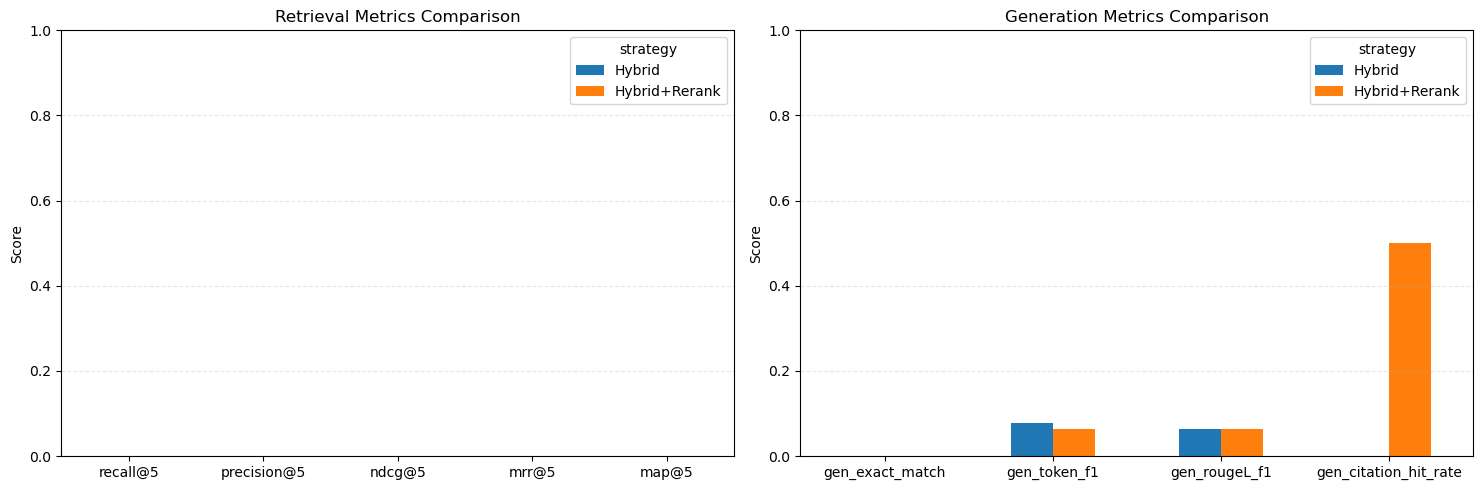

,delta (Rerank - Hybrid)
gen_citation_hit_rate,0.500000
gen_rougeL_f1,0.001007
recall@5,0.000000
precision@5,0.000000
ndcg@5,0.000000
mrr@5,0.000000
map@5,0.000000
gen_exact_match,0.000000
gen_token_f1,-0.012527


In [56]:
def flatten_eval(label, obj):
    row = {"strategy": label}
    row.update(obj.get("retrieval", {}))
    gen = obj.get("generation", {})
    row.update({f"gen_{k}": v for k, v in gen.items()})
    return row

rows = [
    flatten_eval("Hybrid", hybrid),
    flatten_eval("Hybrid+Rerank", hybrid_rerank),
]



if pd is not None:
    df_metrics = pd.DataFrame(rows)
    print("Metrics table:")
    display(df_metrics)

    import matplotlib.pyplot as plt

    df_plot = pd.DataFrame(rows).set_index("strategy")

    retrieval_cols = [c for c in ["recall@5", "precision@5", "ndcg@5", "mrr@5", "map@5"] if c in df_plot.columns]
    gen_cols = [c for c in ["gen_exact_match", "gen_token_f1", "gen_rougeL_f1", "gen_citation_hit_rate"] if c in df_plot.columns]

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    if retrieval_cols:
        df_plot[retrieval_cols].T.plot(kind="bar", ax=axes[0], rot=0)
        axes[0].set_title("Retrieval Metrics Comparison")
        axes[0].set_ylim(0, 1)
        axes[0].set_ylabel("Score")
        axes[0].grid(axis="y", linestyle="--", alpha=0.3)

    if gen_cols:
        df_plot[gen_cols].T.plot(kind="bar", ax=axes[1], rot=0)
        axes[1].set_title("Generation Metrics Comparison")
        axes[1].set_ylim(0, 1)
        axes[1].set_ylabel("Score")
        axes[1].grid(axis="y", linestyle="--", alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Show delta: Hybrid+Rerank minus Hybrid
    if "Hybrid" in df_plot.index and "Hybrid+Rerank" in df_plot.index:
        delta = (df_plot.loc["Hybrid+Rerank"] - df_plot.loc["Hybrid"]).sort_values(ascending=False)
        display(delta.to_frame("delta (Rerank - Hybrid)"))
else:
    print("pandas not available, skipping plot.")



## 6.1) Ablation: compare retrieval/rerank settings

This experiment runs four settings and compares metrics side by side:

- BM25 only
- Hybrid (BM25 + Vector)
- BM25 + Rerank
- Hybrid + Rerank

Use this to diagnose whether score drops come from retrieval quality or reranking.

In [57]:
import os

AB_OUT_DIR = ROOT / "outputs" / "ablation"
AB_OUT_DIR.mkdir(parents=True, exist_ok=True)

experiments = [
    {
        "name": "BM25_only",
        "use_vector": "false",
        "enable_rerank": "false",
    },
    {
        "name": "Hybrid",
        "use_vector": "true",
        "enable_rerank": "false",
    },
    {
        "name": "BM25_plus_Rerank",
        "use_vector": "false",
        "enable_rerank": "true",
    },
    {
        "name": "Hybrid_plus_Rerank",
        "use_vector": "true",
        "enable_rerank": "true",
    },
]


def run_with_env(cmd, env_overrides):
    env = os.environ.copy()
    env.update(env_overrides)
    print("\n$", " ".join(cmd), "\n  env:", env_overrides)
    subprocess.run(cmd, cwd=ROOT, check=True, env=env)


ab_rows = []
for exp in experiments:
    pred_path = AB_OUT_DIR / f"preds_{exp['name']}.jsonl"
    eval_path = AB_OUT_DIR / f"eval_{exp['name']}.json"

    env_overrides = {
        "USE_BM25": "true",
        "USE_VECTOR": exp["use_vector"],
        "ENABLE_RERANK": exp["enable_rerank"],
    }

    run_with_env(
        [
            sys.executable,
            "scripts/eval/run_eval_benchmark.py",
            "--gt",
            str(GT),
            "--out",
            str(pred_path),
            "--enable-rerank",
            exp["enable_rerank"],
        ],
        env_overrides,
    )

    run_with_env(
        [
            sys.executable,
            "scripts/eval/evaluate_predictions.py",
            "--gt",
            str(GT),
            "--pred",
            str(pred_path),
            "--k",
            "5",
            "--out",
            str(eval_path),
        ],
        env_overrides,
    )

    report = json.loads(eval_path.read_text(encoding="utf-8"))
    row = {"experiment": exp["name"]}
    row.update(report.get("retrieval", {}))
    row.update({f"gen_{k}": v for k, v in report.get("generation", {}).items()})
    ab_rows.append(row)

if pd is not None:
    df_ab = pd.DataFrame(ab_rows)
    display(df_ab)
else:
    print(json.dumps(ab_rows, indent=2, ensure_ascii=False))


$ /opt/anaconda3/bin/python scripts/eval/run_eval_benchmark.py --gt /Users/ben/Library/CloudStorage/GoogleDrive-rs.runsheng@gmail.com/My Drive/Colab Notebooks/CS614 GenAI/qa_agent_legal_tax/data/qa_pairs/eval_ground_truth.jsonl --out /Users/ben/Library/CloudStorage/GoogleDrive-rs.runsheng@gmail.com/My Drive/Colab Notebooks/CS614 GenAI/qa_agent_legal_tax/outputs/ablation/preds_BM25_only.jsonl --enable-rerank false 
  env: {'USE_BM25': 'true', 'USE_VECTOR': 'false', 'ENABLE_RERANK': 'false'}
[debug] QAAgent.__init__ signature: (self, retriever, llm_service, validator, config: Dict)
[debug] cfg_dict keys (52): ['ACTS_CHUNKED_DIR', 'ACTS_CSV', 'ACTS_HTML_DIR', 'ACTS_MD_DIR', 'BM25_B', 'BM25_K1', 'CHUNK_OVERLAP', 'CHUNK_SIZE', 'COHERE_API_KEY', 'COHERE_RERANK_MODEL', 'DATA_DIR', 'DEBUG', 'DOCS_DIR', 'EMBEDDING_DIMENSION', 'EMBEDDING_MODEL', 'EMBEDDING_PROVIDER', 'ENABLE_KG', 'ENABLE_RERANK', 'FINANCIAL_TEMPLATES_DIR', 'GEMINI_API_VERSION', 'GEMINI_EMBEDDING_MODEL', 'GEMINI_LLM_MODEL', 'GOO

Cohere rerank skipped: no non-empty candidate documents.
Cohere rerank skipped: no non-empty candidate documents.


Saved predictions: /Users/ben/Library/CloudStorage/GoogleDrive-rs.runsheng@gmail.com/My Drive/Colab Notebooks/CS614 GenAI/qa_agent_legal_tax/outputs/ablation/preds_BM25_only.jsonl (n=2)
[snapshot] Saved run config snapshot: /Users/ben/Library/CloudStorage/GoogleDrive-rs.runsheng@gmail.com/My Drive/Colab Notebooks/CS614 GenAI/qa_agent_legal_tax/outputs/ablation/run_snapshot_20260313_012255.json

$ /opt/anaconda3/bin/python scripts/eval/evaluate_predictions.py --gt /Users/ben/Library/CloudStorage/GoogleDrive-rs.runsheng@gmail.com/My Drive/Colab Notebooks/CS614 GenAI/qa_agent_legal_tax/data/qa_pairs/eval_ground_truth.jsonl --pred /Users/ben/Library/CloudStorage/GoogleDrive-rs.runsheng@gmail.com/My Drive/Colab Notebooks/CS614 GenAI/qa_agent_legal_tax/outputs/ablation/preds_BM25_only.jsonl --k 5 --out /Users/ben/Library/CloudStorage/GoogleDrive-rs.runsheng@gmail.com/My Drive/Colab Notebooks/CS614 GenAI/qa_agent_legal_tax/outputs/ablation/eval_BM25_only.json 
  env: {'USE_BM25': 'true', 'USE

Cohere rerank skipped: no non-empty candidate documents.
Cohere rerank skipped: no non-empty candidate documents.


Saved predictions: /Users/ben/Library/CloudStorage/GoogleDrive-rs.runsheng@gmail.com/My Drive/Colab Notebooks/CS614 GenAI/qa_agent_legal_tax/outputs/ablation/preds_Hybrid.jsonl (n=2)
[snapshot] Saved run config snapshot: /Users/ben/Library/CloudStorage/GoogleDrive-rs.runsheng@gmail.com/My Drive/Colab Notebooks/CS614 GenAI/qa_agent_legal_tax/outputs/ablation/run_snapshot_20260313_012313.json

$ /opt/anaconda3/bin/python scripts/eval/evaluate_predictions.py --gt /Users/ben/Library/CloudStorage/GoogleDrive-rs.runsheng@gmail.com/My Drive/Colab Notebooks/CS614 GenAI/qa_agent_legal_tax/data/qa_pairs/eval_ground_truth.jsonl --pred /Users/ben/Library/CloudStorage/GoogleDrive-rs.runsheng@gmail.com/My Drive/Colab Notebooks/CS614 GenAI/qa_agent_legal_tax/outputs/ablation/preds_Hybrid.jsonl --k 5 --out /Users/ben/Library/CloudStorage/GoogleDrive-rs.runsheng@gmail.com/My Drive/Colab Notebooks/CS614 GenAI/qa_agent_legal_tax/outputs/ablation/eval_Hybrid.json 
  env: {'USE_BM25': 'true', 'USE_VECTOR':

Cohere rerank skipped: no non-empty candidate documents.
Cohere rerank skipped: no non-empty candidate documents.


Saved predictions: /Users/ben/Library/CloudStorage/GoogleDrive-rs.runsheng@gmail.com/My Drive/Colab Notebooks/CS614 GenAI/qa_agent_legal_tax/outputs/ablation/preds_BM25_plus_Rerank.jsonl (n=2)
[snapshot] Saved run config snapshot: /Users/ben/Library/CloudStorage/GoogleDrive-rs.runsheng@gmail.com/My Drive/Colab Notebooks/CS614 GenAI/qa_agent_legal_tax/outputs/ablation/run_snapshot_20260313_012330.json

$ /opt/anaconda3/bin/python scripts/eval/evaluate_predictions.py --gt /Users/ben/Library/CloudStorage/GoogleDrive-rs.runsheng@gmail.com/My Drive/Colab Notebooks/CS614 GenAI/qa_agent_legal_tax/data/qa_pairs/eval_ground_truth.jsonl --pred /Users/ben/Library/CloudStorage/GoogleDrive-rs.runsheng@gmail.com/My Drive/Colab Notebooks/CS614 GenAI/qa_agent_legal_tax/outputs/ablation/preds_BM25_plus_Rerank.jsonl --k 5 --out /Users/ben/Library/CloudStorage/GoogleDrive-rs.runsheng@gmail.com/My Drive/Colab Notebooks/CS614 GenAI/qa_agent_legal_tax/outputs/ablation/eval_BM25_plus_Rerank.json 
  env: {'US

Cohere rerank skipped: no non-empty candidate documents.
Cohere rerank skipped: no non-empty candidate documents.


Saved predictions: /Users/ben/Library/CloudStorage/GoogleDrive-rs.runsheng@gmail.com/My Drive/Colab Notebooks/CS614 GenAI/qa_agent_legal_tax/outputs/ablation/preds_Hybrid_plus_Rerank.jsonl (n=2)
[snapshot] Saved run config snapshot: /Users/ben/Library/CloudStorage/GoogleDrive-rs.runsheng@gmail.com/My Drive/Colab Notebooks/CS614 GenAI/qa_agent_legal_tax/outputs/ablation/run_snapshot_20260313_012346.json

$ /opt/anaconda3/bin/python scripts/eval/evaluate_predictions.py --gt /Users/ben/Library/CloudStorage/GoogleDrive-rs.runsheng@gmail.com/My Drive/Colab Notebooks/CS614 GenAI/qa_agent_legal_tax/data/qa_pairs/eval_ground_truth.jsonl --pred /Users/ben/Library/CloudStorage/GoogleDrive-rs.runsheng@gmail.com/My Drive/Colab Notebooks/CS614 GenAI/qa_agent_legal_tax/outputs/ablation/preds_Hybrid_plus_Rerank.jsonl --k 5 --out /Users/ben/Library/CloudStorage/GoogleDrive-rs.runsheng@gmail.com/My Drive/Colab Notebooks/CS614 GenAI/qa_agent_legal_tax/outputs/ablation/eval_Hybrid_plus_Rerank.json 
  env

,experiment,recall@5,precision@5,ndcg@5,mrr@5,map@5,gen_exact_match,gen_token_f1,gen_rougeL_f1,gen_citation_hit_rate
0,BM25_only,0.0,0.0,0.0,0.0,0.0,0.0,0.081637,0.080883,0.5
1,Hybrid,0.0,0.0,0.0,0.0,0.0,0.0,0.063621,0.061457,0.5
2,BM25_plus_Rerank,0.0,0.0,0.0,0.0,0.0,0.0,0.076253,0.075129,0.5
3,Hybrid_plus_Rerank,0.0,0.0,0.0,0.0,0.0,0.0,0.062131,0.059853,0.5


## 6.2) Experiment Conclusion

This cell prints a clear conclusion and actionable improvement suggestions based on current experiment outputs.

In [58]:
import json
from pathlib import Path


def _safe(v):
    return float(v) if isinstance(v, (int, float)) else 0.0


def _load_json(path: Path):
    if path.exists():
        return json.loads(path.read_text(encoding="utf-8"))
    return None


def _collect_runs():
    runs = {}

    # Prefer ablation outputs when available
    ab_dir = ROOT / "outputs" / "ablation"
    if ab_dir.exists():
        for f in sorted(ab_dir.glob("eval_*.json")):
            name = f.stem.replace("eval_", "")
            obj = _load_json(f)
            if obj:
                runs[name] = obj

    # Fallback to baseline pair
    if not runs:
        if EVAL_HYBRID.exists():
            runs["Hybrid"] = _load_json(EVAL_HYBRID)
        if EVAL_HYBRID_RERANK.exists():
            runs["Hybrid_plus_Rerank"] = _load_json(EVAL_HYBRID_RERANK)

    return {k: v for k, v in runs.items() if v is not None}


runs = _collect_runs()
print("=" * 70)
print("Evaluation Conclusion Log")
print("=" * 70)

if not runs:
    print("[WARN] No evaluation files found. Run the evaluation cells first.")
else:
    # Build compact score table (retrieval avg + generation avg)
    summary = []
    for name, obj in runs.items():
        r = obj.get("retrieval", {})
        g = obj.get("generation", {})

        retrieval_avg = (_safe(r.get("recall@5")) + _safe(r.get("precision@5")) + _safe(r.get("ndcg@5")) + _safe(r.get("mrr@5")) + _safe(r.get("map@5"))) / 5.0
        generation_avg = (_safe(g.get("exact_match")) + _safe(g.get("token_f1")) + _safe(g.get("rougeL_f1")) + _safe(g.get("citation_hit_rate"))) / 4.0

        summary.append({
            "experiment": name,
            "retrieval_avg": retrieval_avg,
            "gen_avg": generation_avg,
            "recall@5": _safe(r.get("recall@5")),
            "mrr@5": _safe(r.get("mrr@5")),
            "gen_token_f1": _safe(g.get("token_f1")),
            "gen_rougeL_f1": _safe(g.get("rougeL_f1")),
            "gen_citation_hit_rate": _safe(g.get("citation_hit_rate")),
        })

    summary = sorted(summary, key=lambda x: (x["gen_avg"], x["retrieval_avg"]), reverse=True)

    if pd is not None:
        display(pd.DataFrame(summary))
    else:
        print(json.dumps(summary, indent=2, ensure_ascii=False))

    best = summary[0]

    print("\n[CONCLUSION]")
    print(f"- Best current setting: {best['experiment']}")
    print(f"- Retrieval avg: {best['retrieval_avg']:.4f}, Generation avg: {best['gen_avg']:.4f}")

    all_retrieval_zero = all(abs(s["retrieval_avg"]) < 1e-12 for s in summary)
    rerank_rows = [s for s in summary if "rerank" in s["experiment"].lower()]
    non_rerank_rows = [s for s in summary if "rerank" not in s["experiment"].lower()]

    if all_retrieval_zero:
        print("- Retrieval metrics are all near zero across runs: rerank has no strong candidate set to improve.")

    if rerank_rows and non_rerank_rows:
        best_rerank = max(rerank_rows, key=lambda x: x["gen_avg"])
        best_non_rerank = max(non_rerank_rows, key=lambda x: x["gen_avg"])
        delta = best_rerank["gen_avg"] - best_non_rerank["gen_avg"]
        print(f"- Rerank effect on best generation avg: {delta:+.4f} (best rerank vs best non-rerank)")

    print("\n[IMPROVEMENT SUGGESTIONS]")
    print("1. Improve first-stage recall before tuning rerank (rerank cannot recover missing relevant docs).")
    print("2. Ensure retrieved_doc_ids are populated and aligned with GT references/doc IDs.")
    print("3. If Gemini embedding quota is limited, run BM25-only baseline and compare after quota recovers.")
    print("4. Expand GT set beyond a single question to reduce metric variance and make conclusions robust.")
    print("5. For citation scoring, keep reference format consistent between GT and predicted citations.")

Evaluation Conclusion Log


,experiment,retrieval_avg,gen_avg,recall@5,mrr@5,gen_token_f1,gen_rougeL_f1,gen_citation_hit_rate
0,BM25_only,0.0,0.165630,0.0,0.0,0.081637,0.080883,0.5
1,BM25_plus_Rerank,0.0,0.162846,0.0,0.0,0.076253,0.075129,0.5
2,Hybrid,0.0,0.156269,0.0,0.0,0.063621,0.061457,0.5
3,Hybrid_plus_Rerank,0.0,0.155496,0.0,0.0,0.062131,0.059853,0.5



[CONCLUSION]
- Best current setting: BM25_only
- Retrieval avg: 0.0000, Generation avg: 0.1656
- Retrieval metrics are all near zero across runs: rerank has no strong candidate set to improve.
- Rerank effect on best generation avg: -0.0028 (best rerank vs best non-rerank)

[IMPROVEMENT SUGGESTIONS]
1. Improve first-stage recall before tuning rerank (rerank cannot recover missing relevant docs).
2. Ensure retrieved_doc_ids are populated and aligned with GT references/doc IDs.
3. If Gemini embedding quota is limited, run BM25-only baseline and compare after quota recovers.
4. Expand GT set beyond a single question to reduce metric variance and make conclusions robust.
5. For citation scoring, keep reference format consistent between GT and predicted citations.


## 7) Reproducibility artifacts

- `outputs/preds_hybrid.jsonl`
- `outputs/preds_hybrid_rerank.jsonl`
- `outputs/eval_hybrid.json`
- `outputs/eval_hybrid_rerank.json`
- `outputs/run_snapshot_YYYYmmdd_HHMMSS.json` (auto-generated by benchmark script)